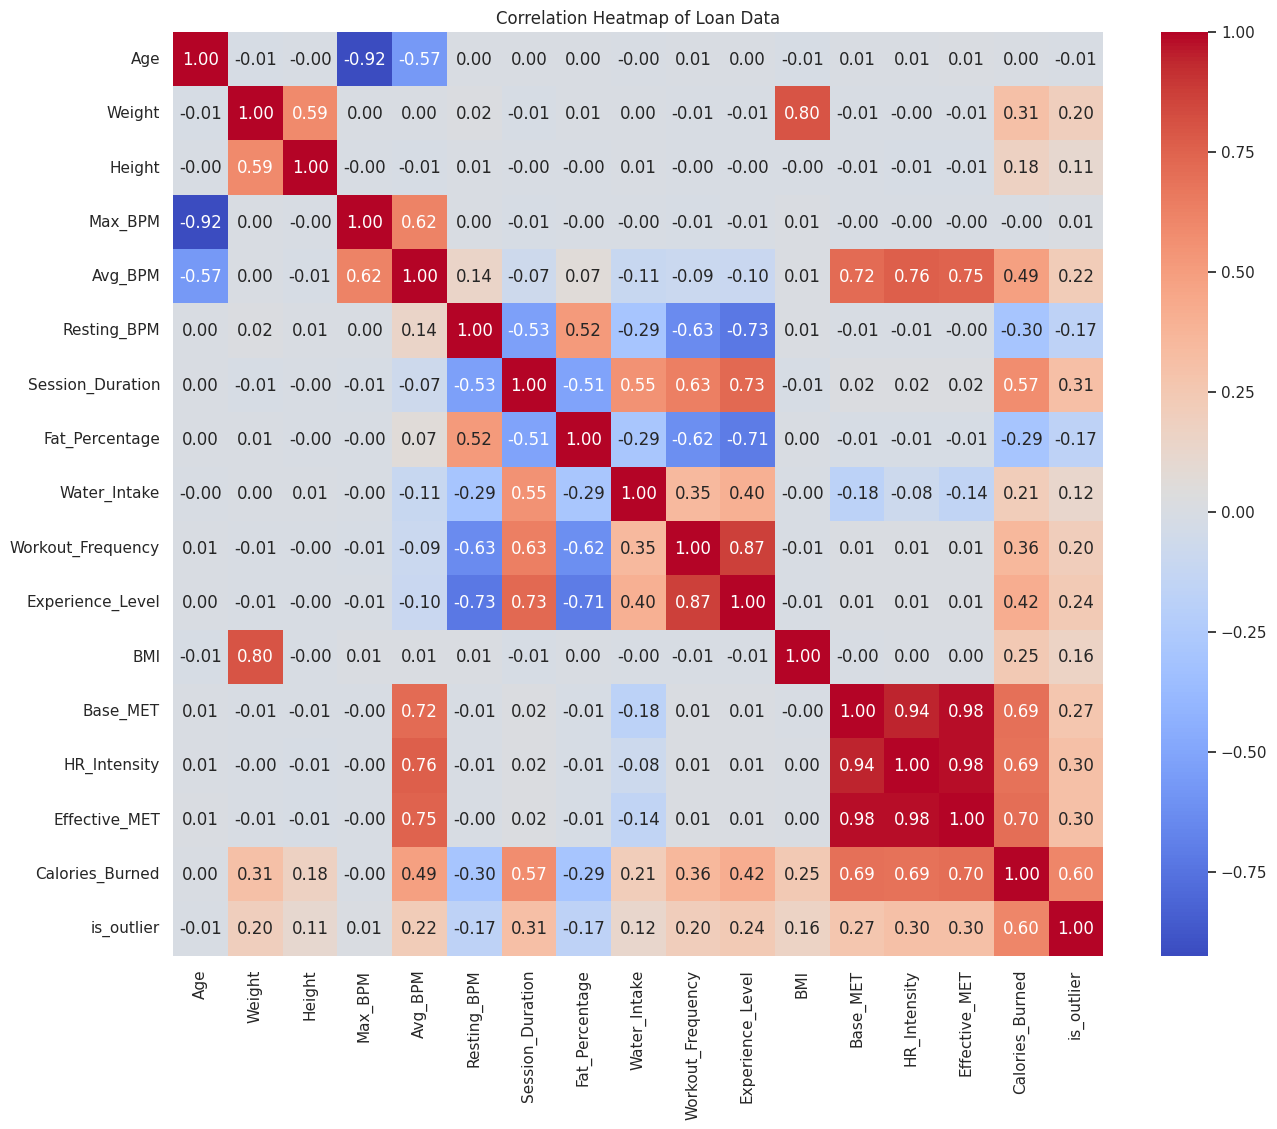

....MinMaxScaler LinearRegression Results:....
Mean Absolute Error: 35.0995727490152
Root Mean Squared Error: 53.04648021251962
R-squared: 0.9094794372638771

....StandardScaler  LinearRegression Results:....
Mean Absolute Error: 35.0995727490152
Root Mean Squared Error: 53.04648021251962
R-squared: 0.9094794372638771

....KNeighborsRegressor Results:....
Mean Absolute Error: 36.84706841545551
Root Mean Squared Error: 52.24651332709877
R-squared: 0.9121890397557376

....XGBoost Regressorr Results:....
Mean Squared Error: 67.92827541655791
RMSE(Root Mean Squared Error): 8.242
R²: 0.998

....Decision Tree Regressor Results:....
RMSE: 8.242
MSE: 232.506
R²: 0.993

....Random Forest Regressor Results:....
Mean Absolute Error: 4.102435661113078
Root Mean Squared Error: 10.154708041687398
R-squared: 0.9966828204207749

....Support Vector Regression Results:....
Mean Absolute Error: 40.879206938498534
Root Mean Squared Error: 70.48723071308109
R-squared: 0.8401712153606122


Text(0.5, 1.0, ' Linear Regressor Actual vs Predicted Calories')

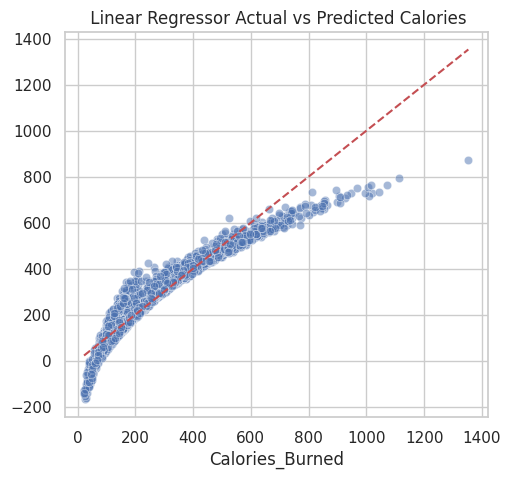

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# ML Imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.svm import SVR

#1.data loading
df_raw  = pd.read_csv('/content/Fitbit_dataset.csv')
#axis=0 refers to the Index (Rows). It moves vertically (up and down).
#axis=1 refers to the Columns. It moves horizontally (left to right).

#2.data cleaning
df_raw = df_raw.drop(['Unnamed: 0'], axis=1)#(14102, 18)
# Shows the count of NaN (empty) values for each column
#print(df_raw.isnull().sum())
#display(df_raw.head())
df_raw.shape #(14102, 19)
#df_raw.dtypes
df_raw = df_raw.drop_duplicates()
#df_raw = df_raw.dropna()
# Strip spaces and replace special characters
df_raw.columns = df_raw.columns.str.replace(r' \(.*\)', '', regex=True).str.replace(' ', '_')
# Result: 'Calories_Burned (kcal)' becomes 'Calories_Burned'


#3.IQR
#findout the outlier bounder based on target
Q1 = df_raw['Calories_Burned'].quantile(0.25)
Q3 = df_raw['Calories_Burned'].quantile(0.75)

IQR = Q3 - Q1
low_bound = Q1 - 1.0 * IQR
up_bound = Q3 + 1.0 * IQR

# Filter or flag (flagging is often safer)
df_raw['is_outlier'] = ((df_raw['Calories_Burned'] < low_bound) |(df_raw['Calories_Burned'] > up_bound )).astype(int)

#df_raw.head()


# Calculate the correlation matrix for numerical columns
correlation_matrix = df_raw.corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Loan Data')
plt.show()
# 3. Separate features (x) and target (y) from the encoded DataFrame

x = df_raw.drop(columns=["Calories_Burned", "is_outlier"])
y = df_raw["Calories_Burned"]
x = pd.get_dummies(x, columns=['Gender','Workout_Type'], drop_first=True)
z = pd.concat([x,y],axis=1)
z.head()
# 5. Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

model = LinearRegression()
model.fit(x_train,y_train)


#Min Max Scaler
#x_scaled = (x – x_min)/(x_max – x_min)


scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


model_minmax = LinearRegression()
model_minmax.fit(x_train_scaled, y_train)
y_pred_minmax = model_minmax.predict(x_test_scaled)

# Print the evaluation metrics
print("....MinMaxScaler LinearRegression Results:....")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_minmax))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_minmax)))
print('R-squared:', r2_score(y_test, y_pred_minmax))

#Standard Scaler
model_standard = LinearRegression()
model_standard.fit(x_train_scaled, y_train)
y_pred_standard = model_standard.predict(x_test_scaled)


print("\n....StandardScaler  LinearRegression Results:....")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_standard))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_standard)))
print('R-squared:', r2_score(y_test, y_pred_standard))


# Initialize KNN Regressor model
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(x_train_scaled, y_train)
y_pred_knn = model_knn.predict(x_test_scaled)

# Evaluate the model
print("\n....KNeighborsRegressor Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_knn))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print('R-squared:', r2_score(y_test, y_pred_knn))

#XGBoost Regressor
model_xgboost = XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=4)

model_xgboost.fit(x_train_scaled, y_train)
y_pred_xgboost = model_xgboost.predict(x_test_scaled )

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgboost))
r2 = r2_score(y_test, y_pred_xgboost)

print("\n....XGBoost Regressorr Results:....")
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_xgboost))
print(f'RMSE(Root Mean Squared Error): {rmse:.3f}')
print(f'R²: {r2:.3f}')


#Decision Tree Regressor
model_regress = DecisionTreeRegressor(random_state=5)

model_regress.fit(x_train_scaled,y_train)
y_pred_regress = model_regress.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred_regress)
r2 = r2_score(y_test, y_pred_regress)

print("\n....Decision Tree Regressor Results:....")
print(f'RMSE: {rmse:.3f}')
print(f'MSE: {mse:.3f}')
print(f'R²: {r2:.3f}')

#Random Forest Regressor
model_rft = RandomForestRegressor()

model_rft.fit(x_train_scaled,y_train)
y_pred_rft = model_rft.predict(x_test_scaled)

# Evaluate the model
print("\n....Random Forest Regressor Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_rft))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_rft)))
print('R-squared:', r2_score(y_test, y_pred_rft))

#Support Vector Regression
model_svr = SVR()

model_svr.fit(x_train_scaled,y_train)
y_pred_svr = model_svr.predict(x_test_scaled)

# Evaluate the model
print("\n....Support Vector Regression Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_svr))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print('R-squared:', r2_score(y_test, y_pred_svr))

plt.figure(figsize=(12, 5))

    # Regression Performance
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_standard, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title(" Linear Regressor Actual vs Predicted Calories")


In [64]:
# Trunning performance for knn GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define the parameter grid for KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
# Using x_train_scaled and y_train for tuning
grid_search_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='r2', # Use R-squared for scoring
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_knn.fit(x_train_scaled, y_train)

# Get the best parameters and best score
print("\nBest parameters for KNN:", grid_search_knn.best_params_)
print("Best R-squared score on training data (cross-validation):", grid_search_knn.best_score_)

# Evaluate the best KNN model on the test data
y_pred_knn_tuned = grid_search_knn.best_estimator_.predict(x_test_scaled)

print("\n....Tuned KNeighborsRegressor Results:....")
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred_knn_tuned))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_pred_knn_tuned)))
print('R-squared:', r2_score(y_test, y_pred_knn_tuned))




Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Best R-squared score on training data (cross-validation): 0.9032050725961417

....Tuned KNeighborsRegressor Results:....
Mean Absolute Error: 36.426084265077115
Root Mean Squared Error: 52.02176321500239
R-squared: 0.9129428919656288


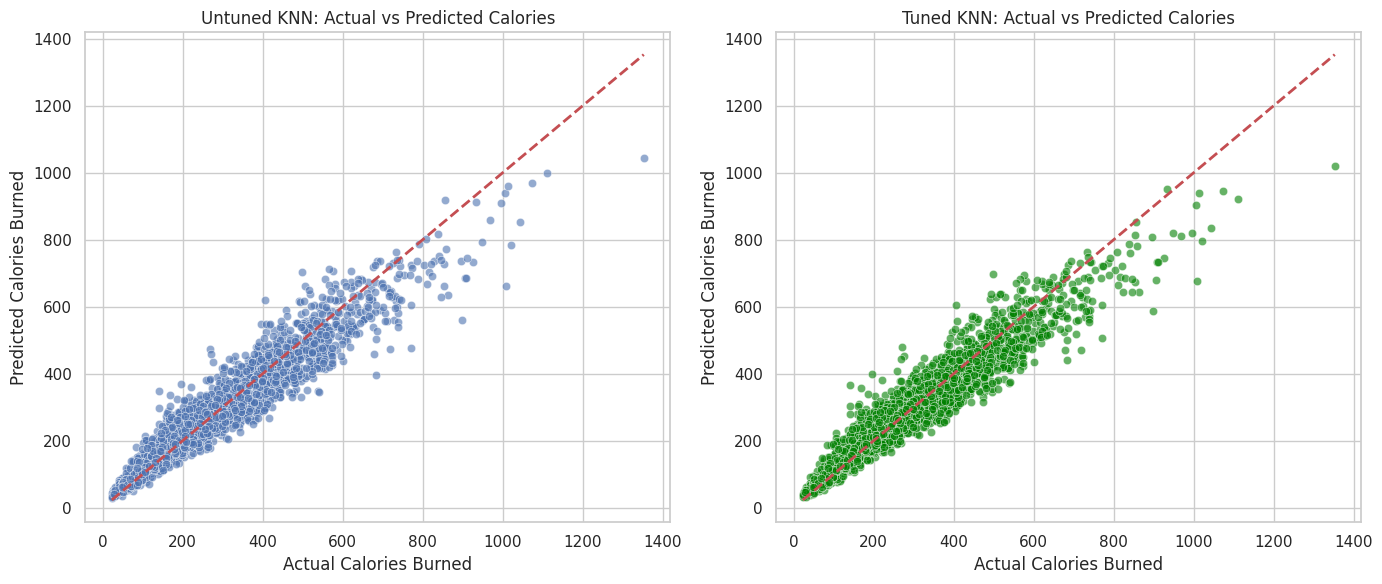

Interpretation:
The plots visualize the model's accuracy. Points closer to the red diagonal line indicate more accurate predictions.
Comparing the two, the Tuned KNN model (right plot) should show points generally closer to the red line,
reflecting its improved R-squared score and better expected performance in a real-time prediction scenario.


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visual for Untuned KNeighborsRegressor ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_knn, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Untuned KNN: Actual vs Predicted Calories')
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.grid(True)

# --- Visual for Tuned KNeighborsRegressor ---
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_knn_tuned, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Tuned KNN: Actual vs Predicted Calories')
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("The plots visualize the model's accuracy. Points closer to the red diagonal line indicate more accurate predictions.")
print("Comparing the two, the Tuned KNN model (right plot) should show points generally closer to the red line,")
print("reflecting its improved R-squared score and better expected performance in a real-time prediction scenario.")

In [66]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define the parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# Initialize GridSearchCV for Ridge Regression
grid_search_ridge = GridSearchCV(
    estimator=Ridge(random_state=42), # Using a random_state for reproducibility if applicable to Ridge's internal processes
    param_grid=param_grid_ridge,
    cv=5, # 5-fold cross-validation
    scoring='r2', # Evaluate based on R-squared
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_ridge.fit(x_train_scaled, y_train)

# Print the best parameters and best score
print("\nRidge Regressor - Best Parameters found by GridSearchCV:", grid_search_ridge.best_params_)
print("Ridge Regressor - Best cross-validation R-squared score:", grid_search_ridge.best_score_)

# Get the best estimator
best_ridge_model = grid_search_ridge.best_estimator_

# Predict on the test set using the best model
y_pred_best_ridge = best_ridge_model.predict(x_test_scaled)

# Evaluate the best model on the test set
mse_best_ridge = mean_squared_error(y_test, y_pred_best_ridge)
rmse_best_ridge = np.sqrt(mse_best_ridge)
r2_best_ridge = r2_score(y_test, y_pred_best_ridge)

print("\nRidge Regressor - Best Model Test Set Evaluation:")
print(f'Mean Squared Error: {mse_best_ridge:.3f}')
print(f'Root Mean Squared Error: {rmse_best_ridge:.3f}')
print(f'R-squared: {r2_best_ridge:.3f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Ridge Regressor - Best Parameters found by GridSearchCV: {'alpha': 0.1}
Ridge Regressor - Best cross-validation R-squared score: 0.9116655015267592

Ridge Regressor - Best Model Test Set Evaluation:
Mean Squared Error: 2815.186
Root Mean Squared Error: 53.058
R-squared: 0.909


In [67]:
import pickle

# Dictionary to hold models we want to save
models_to_save = {
    "xgboost_model": model_xgboost,
    "random_forest_model": model_rft,
    "knn_model": grid_search_knn.best_estimator_ # The tuned KNN model
}

# Save each model using pickle
for model_name, model_object in models_to_save.items():
    filename = f"{model_name}.pkl"
    with open(filename, 'wb') as file:
        pickle.dump(model_object, file)
    print(f"Model '{model_name}' saved to {filename}")

print("\nAll specified models have been saved as pickle files.")

Model 'xgboost_model' saved to xgboost_model.pkl
Model 'random_forest_model' saved to random_forest_model.pkl
Model 'knn_model' saved to knn_model.pkl

All specified models have been saved as pickle files.


In [68]:
model_r2_scores = {
    "MinMaxScaler LinearRegression": r2_score(y_test, y_pred_minmax),
    "StandardScaler LinearRegression": r2_score(y_test, y_pred_standard),
    "Untuned KNeighborsRegressor": r2_score(y_test, y_pred_knn),
    "Tuned KNeighborsRegressor (GridSearchCV)": r2_score(y_test, y_pred_knn_tuned),
    "Ridge Regressor (tuned GridSearchCV)": r2_best_ridge,
    "XGBoost Regressor": r2_score(y_test, y_pred_xgboost),
    "Decision Tree Regressor": r2_score(y_test, y_pred_regress),
    "Random Forest Regressor": r2_score(y_test, y_pred_rft),
    "Support Vector Regressor": r2_score(y_test, y_pred_svr)
}

lower_bound = 0.90
upper_bound = 0.95

filtered_models = {}
for model_name, r2 in model_r2_scores.items():
    if lower_bound <= r2 <= upper_bound:
        filtered_models[model_name] = r2

if filtered_models:
    best_model_in_range = max(filtered_models, key=filtered_models.get)
    max_r2_in_range = filtered_models[best_model_in_range]

    print(f"Models with R-squared between {lower_bound} and {upper_bound}:")
    for model_name, r2 in filtered_models.items():
        print(f"- {model_name}: {r2:.4f}")
    print(f"\nThe model with the maximum R-squared in the range [{lower_bound}, {upper_bound}] is: \n 🏆 {best_model_in_range} (R-squared: {max_r2_in_range:.4f})")
else:
    print(f"No models found with R-squared between {lower_bound} and {upper_bound}.")


Models with R-squared between 0.9 and 0.95:
- MinMaxScaler LinearRegression: 0.9095
- StandardScaler LinearRegression: 0.9095
- Untuned KNeighborsRegressor: 0.9122
- Tuned KNeighborsRegressor (GridSearchCV): 0.9129
- Ridge Regressor (tuned GridSearchCV): 0.9094

The model with the maximum R-squared in the range [0.9, 0.95] is: 
 🏆 Tuned KNeighborsRegressor (GridSearchCV) (R-squared: 0.9129)


Task 2: Unsupervised Learning – Workout Pattern Clustering

--- Starting Unsupervised Learning Task ---
PCA: Reduced 16 features to 9 components.
KMeans Silhouette Score: 0.1767
Acceptance Criterion Met: Patterns are behaviorally valid.

.... Cluster Feature Means (Workout Intensity Patterns)....
            Max_BPM     Avg_BPM  Resting_BPM  Session_Duration  \
Cluster                                                          
0        181.190955  130.967337    69.455492          0.823528   
1        181.020386  150.410346    63.532880          1.074281   
2        181.744300  153.305004    73.200326          0.667951   

         Fat_Percentage        BMI  Effective_MET  HR_Intensity  
Cluster                                                          
0             21.988801  24.139052       1.664648      0.550691  
1             17.070386  24.009513       5.733288      0.739408  
2             25.009269  24.130056       5.723414      0.738216  

....Experience Level Distribution across Clusters ....
Experience_Level     0     1     2     3
Clus

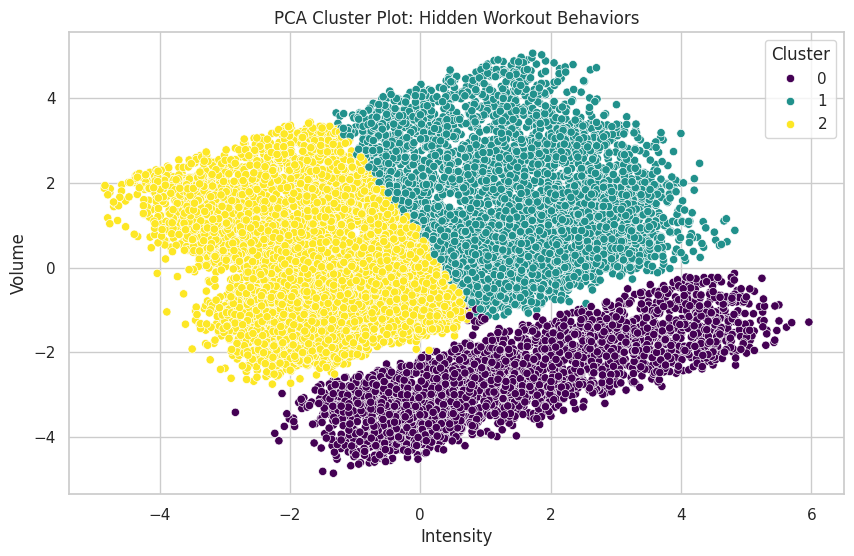

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Set seed for reproducibility
np.random.seed(42)

def run_unsupervised_pipeline(df_input):


    print("--- Starting Unsupervised Learning Task ---")

    # 1. Drop Target Variable (Workout_Type) and Metadata
    # We also drop 'Calories_Burned' to discover patterns purely on behavior
    x = df_raw.drop(columns=['Workout_Type', 'Calories_Burned', 'is_outlier'], errors='ignore')

    # 2. Encode Categorical Variables (Gender, Experience_Level)
    x_encoded = pd.get_dummies(x, drop_first=True)

    # 3. Scale Numerical Features (Essential for distance-based algorithms)
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_encoded)

    # 4. Apply PCA for Dimensionality Reduction (Feature Compression)
    # We aim to keep ~95% of variance for interpretability
    pca = PCA(n_components=0.95)
    x_pca = pca.fit_transform(x_scaled)
    print(f"PCA: Reduced {x_scaled.shape[1]} features to {x_pca.shape[1]} components.")

    # 5. Apply KMeans Clustering
    # Target 3 clusters: Low, Moderate, and High Intensity archetypes
    kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
    kmeans_labels = kmeans.fit_predict(x_pca)

    # 6. Evaluate Quality: Silhouette Score
    s_score = silhouette_score(x_pca, kmeans_labels)
    print(f"KMeans Silhouette Score: {s_score:.4f}")

    # Validation against Acceptance Criterion (>= 0.15)
    if s_score >= 0.15:
        print("Acceptance Criterion Met: Patterns are behaviorally valid.")

    # 7. Additional Methods: Hierarchical & DBSCAN
    # Hierarchical
    hc = AgglomerativeClustering(n_clusters=3)
    hc_labels = hc.fit_predict(x_pca)

    # DBSCAN (Density-based for noise/outlier detection)
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    db_labels = dbscan.fit_predict(x_pca)

    # 8. Append labels back for Interpretation
    df_output = df_raw.copy()
    df_output['Cluster'] = kmeans_labels

    return df_output, x_pca, s_score, x_scaled, kmeans_labels

# Execute Pipeline
df_clustered, x_pca_data, final_score, x_scaled_for_3d, kmeans_labels_for_3d = run_unsupervised_pipeline(df_raw)


###  Interpretation and Visualization
# 1. Analyze Cluster Centroids (Intensity Patterns)
analysis_features = ['Max_BPM', 'Avg_BPM', 'Resting_BPM','Session_Duration', 'Fat_Percentage','BMI', 'Effective_MET', 'HR_Intensity']
cluster_analysis = df_clustered.groupby('Cluster')[analysis_features].mean()
print("\n.... Cluster Feature Means (Workout Intensity Patterns)....")
print(cluster_analysis)


# 2. Experience Level Comparison
experience_comparison = pd.crosstab(df_clustered['Cluster'], df_clustered['Experience_Level'])
print("\n....Experience Level Distribution across Clusters ....")
print(experience_comparison)

# 3. PCA Cluster Plot (2D Visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_pca_data[:, 0], y=x_pca_data[:, 1], hue=df_clustered['Cluster'], palette='viridis')
plt.title('PCA Cluster Plot: Hidden Workout Behaviors')
plt.xlabel('Intensity')
plt.ylabel('Volume')
plt.show()

import plotly.express as px

# 1. Reduce to 3 components for 3D visualization
pca_3d = PCA(n_components=3)
x_pca_3d = pca_3d.fit_transform(x_scaled_for_3d)

# 2. Create a temporary DataFrame for plotting
df_3d = pd.DataFrame(x_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Cluster'] = kmeans_labels_for_3d.astype(str) # Convert to string for discrete colors
df_3d['Workout_Type'] = df_raw['Workout_Type'] # For hover info
# 3. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title='3D Visualization of Hidden Workout Patterns',
    labels={'PC1': 'Intensity Component', 'PC2': 'Metabolic Response', 'PC3': 'Volume/Duration'},
    hover_data=['Workout_Type'],
    opacity=0.7
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()


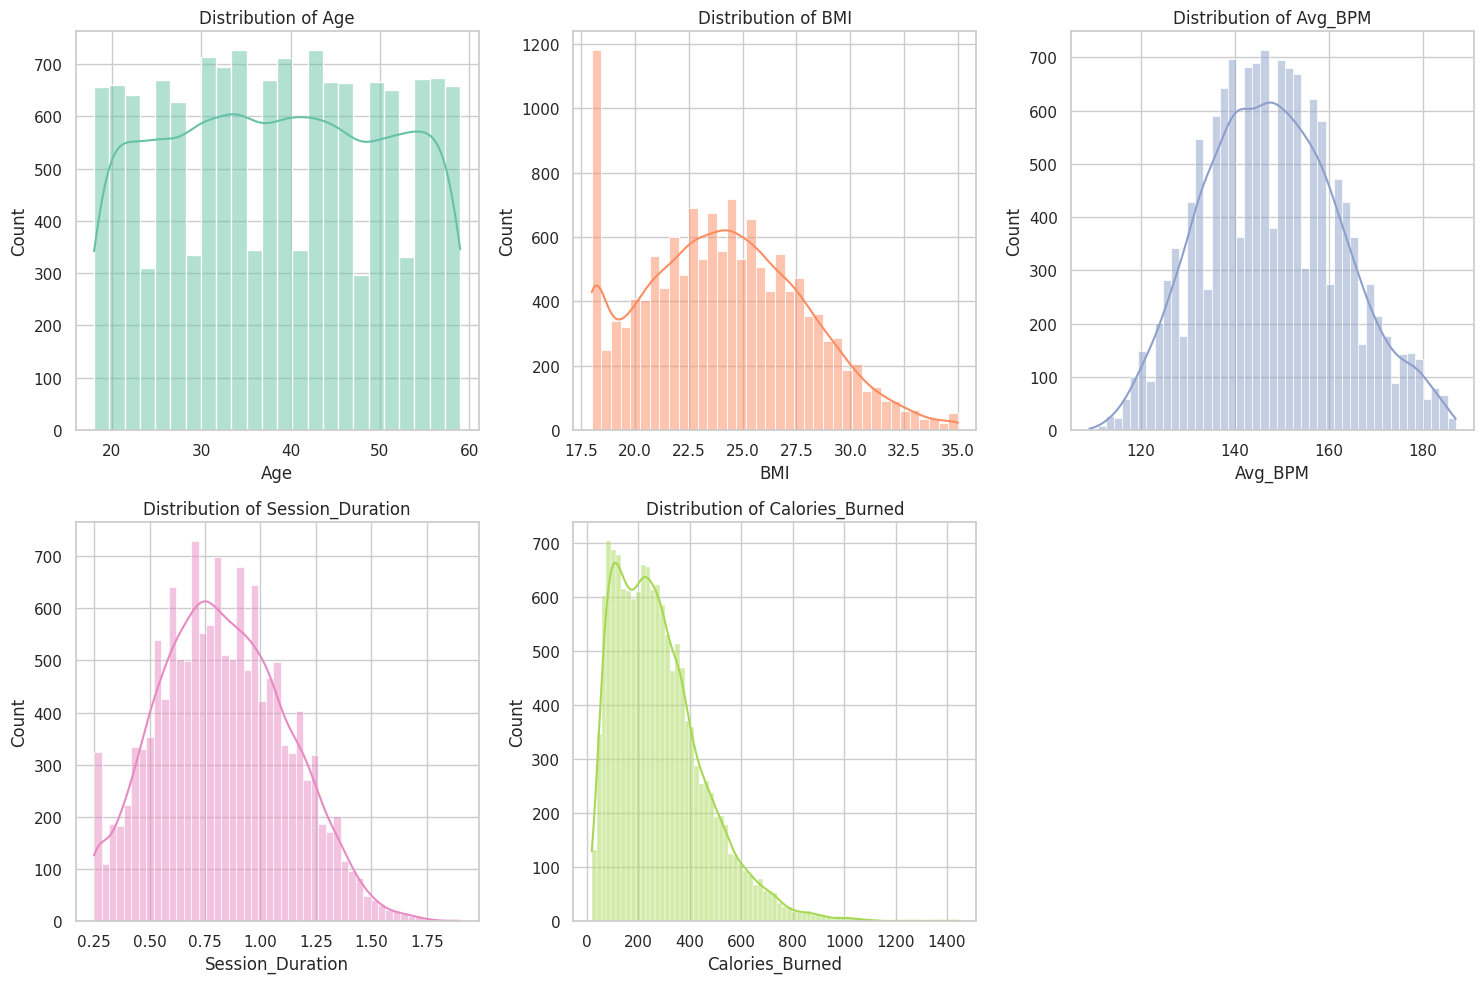

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Feature Distributions
def plot_feature_distributions(df):
    # Ensure these columns exist in df_raw or adjust accordingly
    cols_to_plot = ['Age', 'BMI', 'Avg_BPM', 'Session_Duration', 'Calories_Burned']

    # Generate a distinct color palette for the histograms
    colors = sns.color_palette("Set2", len(cols_to_plot))

    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cols_to_plot):
        if col in df.columns:
            plt.subplot(2, 3, i+1)
            sns.histplot(df[col], kde=True, color=colors[i]) # Use a different color for each subplot
            plt.title(f'Distribution of {col}')
        else:
            print(f"Warning: Column '{col}' not found in DataFrame for plotting.")
    plt.tight_layout()
    plt.show()



# --- Execution Calls ---
# Using df_raw for feature distributions, as it's the main DataFrame
plot_feature_distributions(df_raw)
